# Human Study Question Sampling

Samples **100 questions** for the human study from the 1K VQA control set,
stratified by entity group × operator group (3×3, equal quota).

**Prerequisites:** run `control_tier_analysis.ipynb` first to generate
`analysis/csv/sampled_control_questions.csv` (used for tier priority labels).

**Output:** `analysis/csv/human_study_sample.csv`


In [2]:
import json
import pandas as pd
import numpy as np
import os
import sys
sys.path.insert(0, '/home/david/Desktop/yuna/HPA/analysis')
from utils.vqa import VQAAnswerMapper, vqa_accuracy

RESULTS_DIR    = '/home/david/Desktop/yuna/HPA/evaluation/logits/pretrained'
SEMANTICS_PATH = '/home/david/Desktop/yuna/HPA/dataset/vqa/vqa1k_semantics.jsonl'

mapper = VQAAnswerMapper()

# Full 5-step degradation ladder (pronominalized now complete for all models below)
CONTROL_TYPES = ['question', 'deictic_removed', 'object_removed', 'weaker_object', 'pronominalized']
# Degradation endpoint for Tier D/E (full pronoun ablation — steepest drop)
ABLATED_KEY   = 'pronominalized'

# Models with complete vqa_1k_control.jsonl (all 5 CONTROL_TYPES, 1000 records).
# Incomplete: Qwen3-VL-8B (only pronominalized), llava-v1.6-mistral-7b-hf (12 recs), Qwen3-VL-32B (43 recs)
COMPLETE_MODELS = [
    'InternVL3_5-1B',
    'InternVL3_5-2B',
    'InternVL3_5-8B',
    'Qwen3-VL-2B-Instruct',
    'Qwen3-VL-4B-Instruct',
    'llava-1.5-7b-hf',
    'llava-v1.6-vicuna-13b-hf',
    'llava-v1.6-vicuna-7b-hf',
]

sem_df = pd.read_json(SEMANTICS_PATH, lines=True)[['question_id', 'ent', 'w', 'op', 'attr', 'ans']]
qid_to_ent = dict(zip(sem_df['question_id'], sem_df['ent']))
qid_to_op  = dict(zip(sem_df['question_id'], sem_df['op']))


---

## Ent × Op Stratified Sampling — Signal-Ranked Design

### Design decisions

| Parameter | Value | Rationale |
|-----------|-------|-----------|
| N | **100** | 300 items/rater at 3 variants; fits ~1h session |
| Stratification | **3×3 ent_grp × op_grp** | Ensures entity and operator diversity; 11–12 Qs/cell |
| Quota | **Equal per cell** | No cell dominates; 3×3 gives all cells 11–12 (no pool capping at N=100) |
| Ranking within cell | **Priority → signal_score ↓** | Selects questions with strongest degradation signal first |
| Signal score | `0.5·acc_range + 0.3·acc_std + 0.2·n_unique` | acc_range = effect size (orig→pron); acc_std = curve gradualness; n_unique = output instability across models |
| Flat removal | Questions where all 5 control texts identical | Zero degradation signal — uninformative |

### Group definitions

**Ent (3):** `object` · `person` · `other_ent` (animal + food + place + vehicle + other + text + product)

**Op (3):** `attr` · `count` · `other_op` (exist + spat + ident + act + know + comp + cause + temp + text + other)

### Why 3×3 and not 5×5

The 5×5 grid has multiple cells capped at 5–10 questions (e.g. `other×count = 5`), making equal quotas unachievable. Collapsing to 3×3 raises all cell pools above 24, so N=100 → 11/cell with no capping.
The 3×3 stratification provides **coverage diversity** for the correlation analysis; it is not intended as an inferential grouping.


In [5]:
from utils.vqa import VQAAnswerMapper, vqa_accuracy
from collections import defaultdict

mapper = VQAAnswerMapper()

# ── Group mappings ────────────────────────────────────────────────────────────
ENT_COLLAPSE = {
    'object': 'object', 'person': 'person', 'animal': 'animal',
    'food': 'scene',    'place': 'scene',   'vehicle': 'scene',
    'other': 'other',   'text': 'other',    'product': 'other',
}
OP_COLLAPSE = {
    'attr': 'attr',    'count': 'count',
    'exist': 'local',  'spat': 'local',
    'ident': 'recog',  'act': 'recog',
    'text': 'other_op','know': 'other_op','comp': 'other_op',
    'cause': 'other_op','temp': 'other_op','other': 'other_op',
}

# ── Load control logits for all 8 complete models ─────────────────────────────
print("Loading control logits for 8 complete models...")
acc_by   = defaultdict(lambda: defaultdict(list))   # qid -> ct -> [acc across models]
out_sets = defaultdict(set)                          # qid -> all outputs across CTs + models
flat_ck  = {}                                        # qid -> set of distinct question texts

for m in COMPLETE_MODELS:
    path = f'{RESULTS_DIR}/{m}/vqa_1k_control.jsonl'
    n = 0
    with open(path) as f:
        for line in f:
            ex  = json.loads(line)
            qid = ex['question_id']
            ga  = ex.get('generated_answers', {})
            gt  = mapper.get_answers(qid)
            if qid not in flat_ck:
                flat_ck[qid] = {ex.get(ct, '').strip().lower() for ct in CONTROL_TYPES if ex.get(ct)}
            for ct in CONTROL_TYPES:
                out = ga.get(ct, '').strip()
                acc_by[qid][ct].append(vqa_accuracy(out, gt))
                out_sets[qid].add(out.lower())
            n += 1
    print(f"  {m}: {n} records")

print(f"\nTotal questions with control signals: {len(acc_by)}")


Loading control logits for 8 complete models...
   Loading VQA annotations from /home/david/Desktop/yuna/data/v2_mscoco_val2014_annotations.json...
   ✓ Loaded 214354 VQA annotations
  InternVL3_5-1B: 1000 records
  InternVL3_5-2B: 1000 records
  InternVL3_5-8B: 1000 records
  Qwen3-VL-2B-Instruct: 1000 records
  Qwen3-VL-4B-Instruct: 1000 records
  llava-1.5-7b-hf: 1000 records
  llava-v1.6-vicuna-13b-hf: 1000 records
  llava-v1.6-vicuna-7b-hf: 1000 records

Total questions with control signals: 1000


In [6]:
# ── Build signal_df + merged semantics + tiers ───────────────────────────────
sig_rows = []
for qid, ct_dict in acc_by.items():
    accs = {ct: float(np.mean(v)) for ct, v in ct_dict.items() if v}
    vals_v = [accs.get(ct, np.nan) for ct in CONTROL_TYPES]
    vals_v = [v for v in vals_v if not np.isnan(v)]
    acc_orig = accs.get('question', np.nan)
    acc_pron = accs.get('pronominalized', np.nan)
    acc_range = acc_orig - acc_pron if not (np.isnan(acc_orig) or np.isnan(acc_pron)) else np.nan
    acc_std   = float(np.std(vals_v)) if len(vals_v) > 1 else np.nan
    n_unique  = len(out_sets[qid])
    is_flat   = len(flat_ck.get(qid, set())) <= 1
    sig_rows.append({'question_id': qid, 'acc_original': acc_orig, 'acc_pronominalized': acc_pron,
                     'acc_range': acc_range, 'acc_std': acc_std, 'n_unique': n_unique, 'is_flat': is_flat})

sig_df = pd.DataFrame(sig_rows)

# ── 3×3 group mapping (bottleneck is person×count=24, sets equal quota ceiling) ─
#   ent:  object · person · other_ent (animal+scene+other+text+product)
#   op:   attr   · count  · other_op  (local+recog+know/comp/cause/temp)
ENT3 = {'object':'object', 'person':'person',
        'animal':'other_ent', 'food':'other_ent', 'place':'other_ent',
        'vehicle':'other_ent', 'other':'other_ent', 'text':'other_ent', 'product':'other_ent'}
OP3  = {'attr':'attr', 'count':'count',
        'exist':'other_op', 'spat':'other_op', 'ident':'other_op', 'act':'other_op',
        'text':'other_op', 'know':'other_op', 'comp':'other_op', 'cause':'other_op',
        'temp':'other_op', 'other':'other_op'}

# ── Tier features from TIER_CSV ───────────────────────────────────────────────
TIER_CSV  = '/home/david/Desktop/yuna/HPA/analysis/csv/sampled_control_questions.csv'
tier_df   = pd.read_csv(TIER_CSV)[['question_id','overconfident_wrong','mean_output_changes',
                                    'consensus_wrong','acc_drop','conf_drop','acc_baseline']]
tier_df   = tier_df.rename(columns={'acc_drop':'acc_drop_tier','acc_baseline':'acc_base_tier'})

full_df = (sig_df
    .merge(sem_df[['question_id','ent','op','w','ans']], on='question_id')
    .merge(tier_df, on='question_id', how='left'))
full_df['ent_grp'] = full_df['ent'].map(ENT3).fillna('other_ent')
full_df['op_grp']  = full_df['op'].map(OP3).fillna('other_op')
full_df['cell']    = full_df['ent_grp'] + '|' + full_df['op_grp']

full_df['tier_A'] = full_df['overconfident_wrong'].fillna(False).astype(bool)
full_df['tier_B'] = full_df['mean_output_changes'].fillna(0) > 2
full_df['tier_C'] = full_df['consensus_wrong'].fillna(False).astype(bool)
full_df['tier_D'] = full_df['acc_drop_tier'].fillna(0) > 0.3
full_df['tier_E'] = (full_df['conf_drop'].fillna(0) > 0.05) & (full_df['acc_base_tier'].fillna(0) > 0.5)
full_df['tiers_str'] = full_df.apply(
    lambda r: '|'.join([t for t,b in zip(['A','B','C','D','E'],
                        [r.tier_A,r.tier_B,r.tier_C,r.tier_D,r.tier_E]) if b]), axis=1)
full_df['priority'] = full_df.apply(
    lambda r: 1 if r.tier_A else 2 if r.tier_B else 3 if (r.tier_C or r.tier_D or r.tier_E) else 4, axis=1)

nf = full_df[~full_df['is_flat']].copy()

def norm(s): return (s - s.min()) / (s.max() - s.min() + 1e-9)
nf = nf.copy()
nf['signal_score'] = (0.5 * norm(nf['acc_range'].fillna(0))
                    + 0.3 * norm(nf['acc_std'].fillna(0))
                    + 0.2 * norm(nf['n_unique'].fillna(0)))

print(f"Non-flat pool: {len(nf)} / {len(full_df)}")
print(f"Signal score: mean={nf['signal_score'].mean():.3f}  range=[{nf['signal_score'].min():.3f}, {nf['signal_score'].max():.3f}]")

print("\n=== 3×3 pool sizes (non-flat) ===")
pool_ct = nf.groupby(['ent_grp','op_grp']).size().unstack(fill_value=0)
print(pool_ct)
print(f"\nBottleneck: person×count = {pool_ct.loc['person','count']} questions (sets equal quota ceiling at 24)")
print(f"Total non-flat: {len(nf)}  |  Tier A/B/C/D/E: {nf.tier_A.sum()}/{nf.tier_B.sum()}/{nf.tier_C.sum()}/{nf.tier_D.sum()}/{nf.tier_E.sum()}")


Non-flat pool: 925 / 1000
Signal score: mean=0.323  range=[0.186, 0.901]

=== 3×3 pool sizes (non-flat) ===
op_grp     attr  count  other_op
ent_grp                         
object      166     37       131
other_ent   147     37       197
person       85     24       101

Bottleneck: person×count = 24 questions (sets equal quota ceiling at 24)
Total non-flat: 925  |  Tier A/B/C/D/E: 33/58/28/167/218


In [7]:
# ── Equal-quota allocator ─────────────────────────────────────────────────────
def equal_quota_allocate(pool_counts: dict, n: int) -> dict:
    cells = sorted(pool_counts)
    quotas = {c: 0 for c in cells}
    remaining, uncapped = n, set(cells)
    while remaining > 0 and uncapped:
        base = remaining // len(uncapped)
        if base == 0:
            for c in sorted(uncapped, key=lambda c: pool_counts[c], reverse=True):
                if remaining <= 0: break
                quotas[c] += 1; remaining -= 1
            break
        newly_capped = [c for c in uncapped if pool_counts[c] - quotas[c] <= base]
        if not newly_capped:
            r = remaining % len(uncapped)
            for c in sorted(uncapped, key=lambda c: pool_counts[c], reverse=True):
                q = min(base + (1 if r > 0 else 0), pool_counts[c] - quotas[c])
                quotas[c] += q; remaining -= q
                if r > 0: r -= 1
            break
        for c in newly_capped:
            add = pool_counts[c] - quotas[c]; quotas[c] += add; remaining -= add
        uncapped -= set(newly_capped)
    return quotas


def sample_3x3(pool: pd.DataFrame, n: int, seed: int = 42) -> pd.DataFrame:
    """
    Equal-quota sampling across 3×3 ent_grp × op_grp cells.
    Within each cell: priority (asc) then signal_score (desc).

    At N=100: 11-12 per cell, no pool capping (all cells ≥ 24 in pool).
    """
    cell_counts = pool['cell'].value_counts().to_dict()
    quotas = equal_quota_allocate(cell_counts, n)

    print(f"Quota allocation (total={sum(quotas.values())}):")
    for cell in sorted(quotas):
        ent_g, op_g = cell.split('|')
        print(f"  {ent_g:12s} × {op_g:10s}: quota={quotas[cell]:3d}  pool={cell_counts[cell]}")

    parts = []
    for cell, quota in quotas.items():
        if quota == 0: continue
        sub = pool[pool['cell'] == cell].sort_values(
            ['priority', 'signal_score'], ascending=[True, False])
        parts.append(sub.head(quota))

    return pd.concat(parts).sample(frac=1, random_state=seed).reset_index(drop=True), quotas


N_SAMPLE = 100
sampled, quotas = sample_3x3(nf, N_SAMPLE)

print(f"\n=== Sampled {len(sampled)} questions ===")
print("\nEnt × Op cross-tab:")
print(sampled.groupby(['ent_grp', 'op_grp']).size().unstack(fill_value=0))
print(f"\nPriority breakdown:")
lbl = {1:'A overconfident_wrong', 2:'B answer_flip', 3:'C/D/E degradation', 4:'fill (signal-ranked)'}
for p, l in lbl.items():
    print(f"  P{p} {l}: {(sampled['priority']==p).sum()}")
print(f"\nMean signal_score: {sampled['signal_score'].mean():.3f}  (pool: {nf['signal_score'].mean():.3f})")
print(f"Mean acc_range:    {sampled['acc_range'].mean():.3f}  (pool: {nf['acc_range'].mean():.3f})")


Quota allocation (total=100):
  object       × attr      : quota= 11  pool=166
  object       × count     : quota= 11  pool=37
  object       × other_op  : quota= 11  pool=131
  other_ent    × attr      : quota= 11  pool=147
  other_ent    × count     : quota= 11  pool=37
  other_ent    × other_op  : quota= 12  pool=197
  person       × attr      : quota= 11  pool=85
  person       × count     : quota= 11  pool=24
  person       × other_op  : quota= 11  pool=101

=== Sampled 100 questions ===

Ent × Op cross-tab:
op_grp     attr  count  other_op
ent_grp                         
object       11     11        11
other_ent    11     11        12
person       11     11        11

Priority breakdown:
  P1 A overconfident_wrong: 33
  P2 B answer_flip: 41
  P3 C/D/E degradation: 21
  P4 fill (signal-ranked): 5

Mean signal_score: 0.498  (pool: 0.323)
Mean acc_range:    0.350  (pool: 0.116)


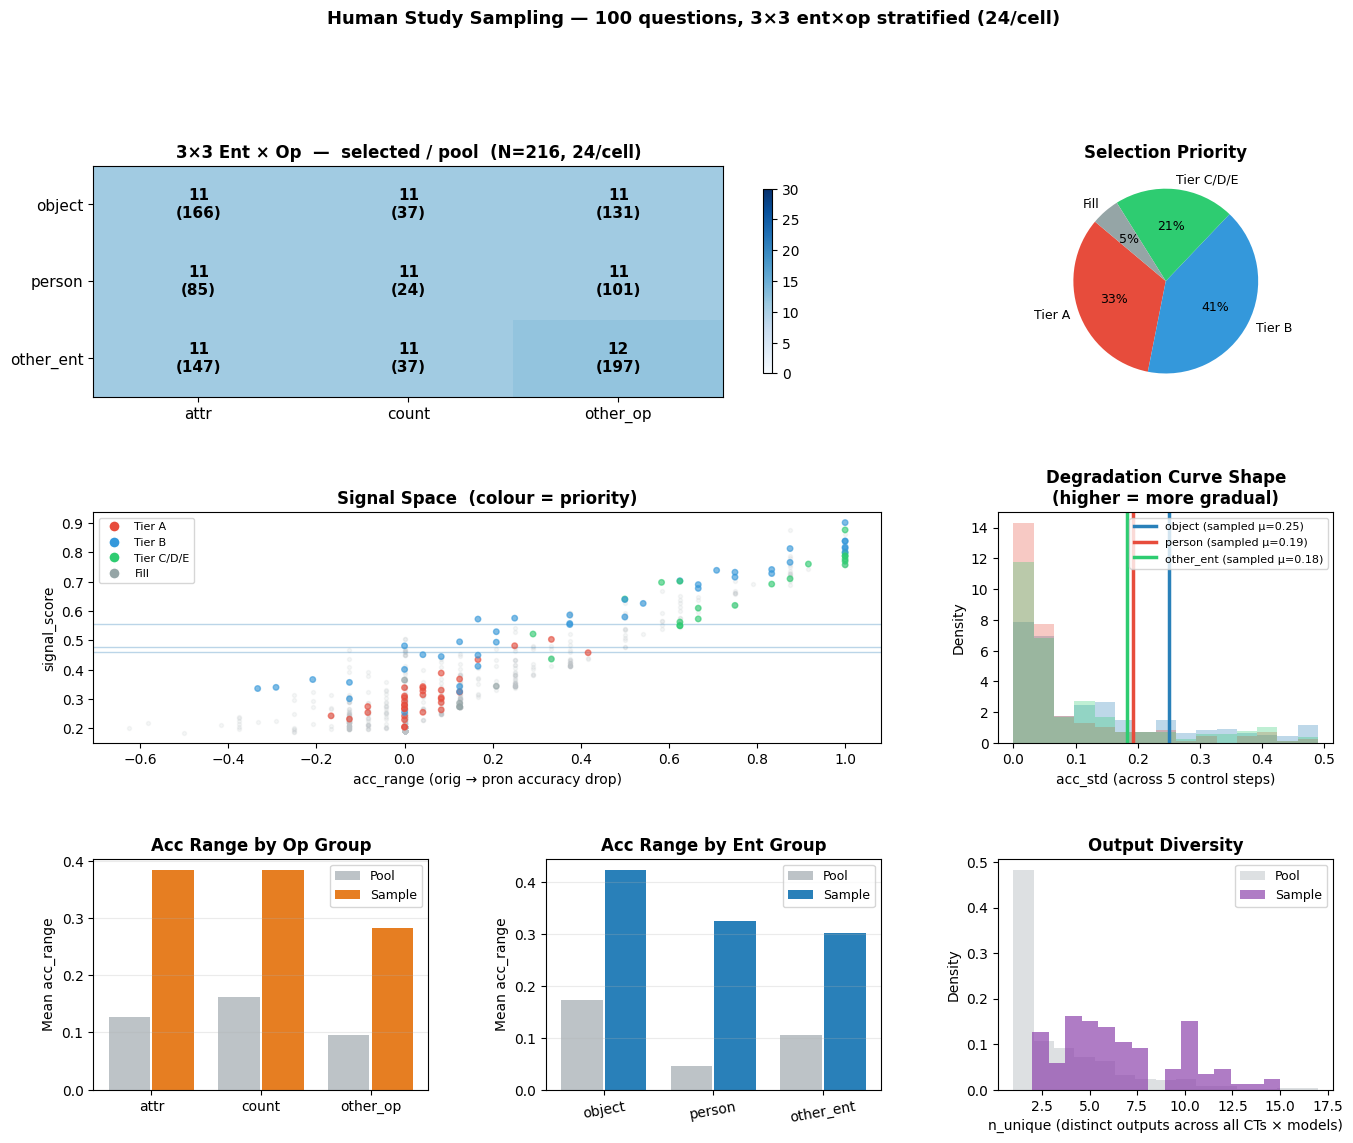

Saved: /home/david/Desktop/yuna/HPA/analysis/figures/sampling_3x3_stratified.png


In [8]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

ENT_ORD = ['object', 'person', 'other_ent']
OP_ORD  = ['attr', 'count', 'other_op']
TIER_COLORS = {1:'#e74c3c', 2:'#3498db', 3:'#2ecc71', 4:'#95a5a6'}
TIER_LABELS = {1:'Tier A', 2:'Tier B', 3:'Tier C/D/E', 4:'Fill'}

fig = plt.figure(figsize=(16, 12))
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.5, wspace=0.35)

# ── (0, 0-1) 3×3 cross-tab: selected vs pool ─────────────────────────────────
ax0 = fig.add_subplot(gs[0, :2])
pool_ct   = nf.groupby(['ent_grp', 'op_grp']).size().unstack(fill_value=0)
samp_ct   = sampled.groupby(['ent_grp', 'op_grp']).size().unstack(fill_value=0)
pool_ct   = pool_ct.reindex(index=ENT_ORD, columns=OP_ORD, fill_value=0)
samp_ct   = samp_ct.reindex(index=ENT_ORD, columns=OP_ORD, fill_value=0)
im = ax0.imshow(samp_ct.values, cmap='Blues', aspect='auto', vmin=0, vmax=30)
for r in range(3):
    for c in range(3):
        sv, pv = samp_ct.values[r,c], pool_ct.values[r,c]
        ax0.text(c, r, f"{sv}\n({pv})", ha='center', va='center',
                 fontsize=11, color='white' if sv>18 else 'black', fontweight='bold')
ax0.set_xticks([0,1,2]); ax0.set_xticklabels(OP_ORD, fontsize=11)
ax0.set_yticks([0,1,2]); ax0.set_yticklabels(ENT_ORD, fontsize=11)
ax0.set_title('3×3 Ent × Op  —  selected / pool  (N=216, 24/cell)', fontweight='bold', fontsize=12)
plt.colorbar(im, ax=ax0, shrink=0.8)

# ── (0, 2) Priority pie ───────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 2])
pri_counts = [(sampled['priority']==p).sum() for p in [1,2,3,4]]
wedges, _, autotexts = ax1.pie(
    pri_counts, labels=[TIER_LABELS[p] for p in [1,2,3,4]],
    colors=[TIER_COLORS[p] for p in [1,2,3,4]],
    autopct=lambda p: f'{p:.0f}%' if p>3 else '', startangle=140,
    textprops={'fontsize':9})
ax1.set_title('Selection Priority', fontweight='bold')

# ── (1, full) Signal score vs acc_range scatter ───────────────────────────────
ax2 = fig.add_subplot(gs[1, :2])
ax2.scatter(nf['acc_range'], nf['signal_score'], alpha=0.15, s=8, c='#bdc3c7', label='pool')
ax2.scatter(sampled['acc_range'], sampled['signal_score'], alpha=0.6, s=16,
            c=[TIER_COLORS[p] for p in sampled['priority']], zorder=3, label='sampled')
for ent in ENT_ORD:
    s = sampled[sampled['ent_grp']==ent]
    ax2.axhline(s['signal_score'].mean(), alpha=0.3, linewidth=1)
ax2.set_xlabel('acc_range (orig → pron accuracy drop)'); ax2.set_ylabel('signal_score')
ax2.set_title('Signal Space  (colour = priority)', fontweight='bold')
from matplotlib.lines import Line2D
ax2.legend(handles=[Line2D([0],[0],marker='o',color='w',markerfacecolor=TIER_COLORS[p],
           markersize=8,label=TIER_LABELS[p]) for p in [1,2,3,4]], fontsize=8)

# ── (1, 2) acc_std by ent group ────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 2])
colors_e = ['#2980b9','#e74c3c','#2ecc71']
for i, ent in enumerate(ENT_ORD):
    vals  = nf[nf['ent_grp']==ent]['acc_std'].dropna().values
    svals = sampled[sampled['ent_grp']==ent]['acc_std'].dropna().values
    ax3.hist(vals, bins=15, alpha=0.3, color=colors_e[i], density=True)
    ax3.axvline(svals.mean(), color=colors_e[i], linewidth=2.5, label=f'{ent} (sampled μ={svals.mean():.2f})')
ax3.set_xlabel('acc_std (across 5 control steps)'); ax3.set_ylabel('Density')
ax3.set_title('Degradation Curve Shape\n(higher = more gradual)', fontweight='bold')
ax3.legend(fontsize=8)

# ── (2, 0) acc_range by op group: pool vs sampled ────────────────────────────
ax4 = fig.add_subplot(gs[2, 0])
x = np.arange(3)
pm = [nf[nf['op_grp']==o]['acc_range'].mean() for o in OP_ORD]
sm = [sampled[sampled['op_grp']==o]['acc_range'].mean() for o in OP_ORD]
ax4.bar(x-0.2, pm, 0.38, color='#bdc3c7', label='Pool')
ax4.bar(x+0.2, sm, 0.38, color='#e67e22', label='Sample')
ax4.set_xticks(x); ax4.set_xticklabels(OP_ORD, fontsize=10)
ax4.set_ylabel('Mean acc_range'); ax4.set_title('Acc Range by Op Group', fontweight='bold')
ax4.legend(fontsize=9); ax4.grid(axis='y', alpha=0.25)

# ── (2, 1) acc_range by ent group ────────────────────────────────────────────
ax5 = fig.add_subplot(gs[2, 1])
pm2 = [nf[nf['ent_grp']==e]['acc_range'].mean() for e in ENT_ORD]
sm2 = [sampled[sampled['ent_grp']==e]['acc_range'].mean() for e in ENT_ORD]
ax5.bar(x-0.2, pm2, 0.38, color='#bdc3c7', label='Pool')
ax5.bar(x+0.2, sm2, 0.38, color='#2980b9', label='Sample')
ax5.set_xticks(x); ax5.set_xticklabels(ENT_ORD, fontsize=10, rotation=10)
ax5.set_ylabel('Mean acc_range'); ax5.set_title('Acc Range by Ent Group', fontweight='bold')
ax5.legend(fontsize=9); ax5.grid(axis='y', alpha=0.25)

# ── (2, 2) n_unique distribution ─────────────────────────────────────────────
ax6 = fig.add_subplot(gs[2, 2])
ax6.hist(nf['n_unique'], bins=15, alpha=0.5, color='#bdc3c7', label='Pool', density=True)
ax6.hist(sampled['n_unique'], bins=15, alpha=0.7, color='#8e44ad', label='Sample', density=True)
ax6.set_xlabel('n_unique (distinct outputs across all CTs × models)'); ax6.set_ylabel('Density')
ax6.set_title('Output Diversity', fontweight='bold'); ax6.legend(fontsize=9)

plt.suptitle(f'Human Study Sampling — {N_SAMPLE} questions, 3×3 ent×op stratified (24/cell)',
             fontsize=13, fontweight='bold', y=1.01)
fig_path = '/home/david/Desktop/yuna/HPA/analysis/figures/sampling_3x3_stratified.png'
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {fig_path}")


In [ ]:
# ── Statistical Power Analysis ────────────────────────────────────────────────
import scipy.stats as stats
from scipy.stats import norm as snorm

N_Q, N_R, N_CT, ALPHA = len(sampled), 25, 3, 0.05
N_CELLS = 9                    # 3×3, 11-12 Qs per cell
N_PER_CELL_Q = N_Q // N_CELLS  # ≈ 11

def pw_r(n, r):
    z = np.arctanh(r); se = 1 / np.sqrt(n - 3)
    return snorm.cdf(abs(z) / se - snorm.ppf(1 - ALPHA/2))

def pw_paired(n, d):
    return snorm.cdf(abs(d) * np.sqrt(n) - snorm.ppf(1 - ALPHA/2))

def pw_2samp(n, d):
    return snorm.cdf(abs(d) / np.sqrt(2 / n) - snorm.ppf(1 - ALPHA/2))

print('=' * 62)
print(f'  Power Analysis  |  N_q={N_Q}  N_raters={N_R}  N_variants={N_CT}')
print('=' * 62)

# ── PRIMARY: correlation human difficulty vs model ────────────────────────────
# From existing study: observed r = 0.50–0.72 (inst_blind), so expected ≈ 0.50+
print('\n[PRIMARY] Correlation: human difficulty curve vs model accuracy')
print('          Unit = question (N=100)  |  Expected r ≈ 0.50–0.62 from existing study')
for r in [0.20, 0.30, 0.40, 0.50, 0.60]:
    pw = pw_r(N_Q, r)
    flag = '✓' if pw >= 0.8 else '✗ below threshold'
    print(f'  r={r:.2f}: power={pw:.3f}  {flag}')
print('  Detection floor: r ≥ 0.30 at power=0.80')
print('  → N=100 is sufficient given expected effect sizes.')

# ── SECONDARY: human degradation across 3 variants ───────────────────────────
print('\n[2] Human degradation: orig → weaker_obj → pron  (repeated-measures, N=100 Qs)')
print('    One-way ANOVA equivalent / paired t for each step:')
for d in [0.2, 0.3, 0.5]:
    pw = pw_paired(N_Q, d)
    print(f'  d={d:.1f}: power={pw:.3f}  {"✓" if pw>=0.8 else "✗"}')

# ── TERTIARY: cell-level descriptive ─────────────────────────────────────────
print(f'\n[3] Cell-level comparisons  (11 Qs/cell = {N_PER_CELL_Q*N_R} responses/cell)')
print('    (a) Question-level t-test (n=11 per cell) — NOT recommended:')
for d in [0.5, 0.8]:
    print(f'        d={d:.1f}: power={pw_2samp(N_PER_CELL_Q,d):.3f}  ← weak')
print('    (b) Response-level LMM (n=275 responses per cell):')
for d in [0.2, 0.3]:
    pw = pw_2samp(N_PER_CELL_Q*N_R, d)
    print(f'        d={d:.1f}: power={pw:.3f}  {"✓" if pw>=0.8 else "~"}')
print('    → Use 3×3 cells for descriptive stratification,')
print('      not for inferential comparisons. Primary claim is correlation.')

# ── Study burden ──────────────────────────────────────────────────────────────
print(f'\n[Study burden]')
print(f'  Items per rater: {N_Q} Qs × {N_CT} variants = {N_Q*N_CT}  (~55–75 min)')
print(f'  Total responses: {N_Q} × {N_CT} × {N_R} = {N_Q*N_CT*N_R:,}')

# ── ICC extrapolation ─────────────────────────────────────────────────────────
icc0, k0 = 0.963, 20
rho1 = icc0 / (k0 - (k0-1)*icc0)
print(f'\n[ICC] Extrapolated from existing study (ICC=0.963, k=20):')
for k in [20, 25, 30]:
    icc_k = k*rho1/(1+(k-1)*rho1)
    print(f'  k={k}: ICC≈{icc_k:.3f}  ✓')

print('\n' + '=' * 62)
print('Verdict:')
print('  ✓  Primary (correlation, r≥0.30): N=100 sufficient')
print('  ✓  Degradation (paired, d≥0.30): N=100 sufficient')
print('  ⚠  Cell-level t-tests at question level: underpowered (n=11)')
print('  ✓  Response-level LMM with rater random effect: d≥0.3 detectable')
print('  ✓  3×3 stratification provides coverage diversity, not inferential cells')

print()
print('=== Analysis design separation ===')
print('  ent×op cell characterization → MODEL analysis (§4-5)')
print('    Use full 1K dataset × 8 models: well-powered for all cells')
print('    Already in analysis-pretrained.ipynb / abstention_analysis.ipynb')
print()
print('  Human-model alignment → HUMAN study (§6)')
print('    N=100 Qs × 25 raters: powered for correlation (primary)')
print('    3×3 stratification = sampling diversity, NOT inferential grouping')
print()
print('  Do NOT attempt per-cell human analysis (11 Qs/cell → underpowered)')


  Power Analysis  |  N_q=100  N_raters=25  N_variants=3

[PRIMARY] Correlation: human difficulty curve vs model accuracy
          Unit = question (N=100)  |  Expected r ≈ 0.50–0.62 from existing study
  r=0.20: power=0.515  ✗ below threshold
  r=0.30: power=0.862  ✓
  r=0.40: power=0.987  ✓
  r=0.50: power=1.000  ✓
  r=0.60: power=1.000  ✓
  Detection floor: r ≥ 0.30 at power=0.80
  → N=100 is sufficient given expected effect sizes.

[2] Human degradation: orig → weaker_obj → pron  (repeated-measures, N=100 Qs)
    One-way ANOVA equivalent / paired t for each step:
  d=0.2: power=0.516  ✗
  d=0.3: power=0.851  ✓
  d=0.5: power=0.999  ✓

[3] Cell-level comparisons  (11 Qs/cell = 275 responses/cell)
    (a) Question-level t-test (n=11 per cell) — NOT recommended:
        d=0.5: power=0.216  ← weak
        d=0.8: power=0.467  ← weak
    (b) Response-level LMM (n=275 responses per cell):
        d=0.2: power=0.650  ~
        d=0.3: power=0.940  ✓
    → Use 3×3 cells for descriptive strati

---

## Which Control Types to Show Humans

### Degradation ladder (5 steps)

| Variant | Example | Human signal | Model signal | Verdict |
|---------|---------|-------------|--------------|---------|
| `question` | "How many dogs are in the park?" | Baseline (linguistic priors) | Baseline | **Include** |
| `deictic_removed` | "How many dogs in the park?" *(no 'this/that')* | ≈ identical to original | Minor | **Skip** — trivially easy |
| `object_removed` | "How many **objects** are in the park?" | Unanswerable — humans say "can't tell" | Strong | **Skip** — disrupts prior activation |
| `weaker_object` | "How many **animals** are in the park?" | Partial — hypernym primes partial knowledge | Clear midpoint | **Include** |
| `pronominalized` | "How many of **them** are in the park?" | Near-chance — zero entity info | Endpoint | **Include** |

### Recommendation: **3 variants — `question`, `weaker_object`, `pronominalized`**

**Why these 3:**
- Endpoints (`question`, `pronominalized`) establish the degradation effect — required for the core claim
- `weaker_object` reveals *where* the cliff is: after the hypernym or only after the pronoun? This separates referential grounding from semantic class knowledge
- Skipping `deictic_removed` (no human signal) and `object_removed` (disrupts prior activation rather than testing it) keeps the burden minimal

### Final study design

| Parameter | Value | Notes |
|-----------|-------|-------|
| Questions | **100** | 11–12 per ent×op cell (3×3 grid) |
| Variants per question | **3** (question · weaker_object · pronominalized) | |
| Raters | **25** | All see the same 100 questions |
| Items per rater | **300** | ~55–75 min |
| Total responses | **7,500** | |
| Primary analysis | Pearson r: human difficulty vs model accuracy | N=100 Qs; detection floor r≥0.30 |
| Secondary analysis | Repeated-measures: degradation orig→weaker→pron | d≥0.30, power=0.85 |
| Tertiary | LMM with ent/op group interactions | `accuracy ~ variant × ent_grp + (1|q) + (1|rater)` |
| 3×3 grid purpose | Coverage diversity | Not powered for inferential cell comparisons |

**Note on human vs LLM substitution:** the correlation target is model behavior from the logit
inference runs — human responses are irreplaceable here. An LLM generating "human-like"
answers would just reproduce model priors, not human linguistic priors.


In [11]:
# ── Save final sample ─────────────────────────────────────────────────────────
OUT_PATH = '/home/david/Desktop/yuna/HPA/analysis/csv/human_study_sample.csv'

save_cols = [
    'question_id', 'question_text', 'ent', 'op', 'ent_grp', 'op_grp', 'cell',
    'acc_original', 'acc_pronominalized', 'acc_range', 'acc_std', 'n_unique',
    'signal_score', 'priority', 'tiers_str',
    'tier_A', 'tier_B', 'tier_C', 'tier_D', 'tier_E',
]
# pull question_text from sem_df if not already in sampled
if 'question_text' not in sampled.columns:
    sampled = sampled.merge(sem_df[['question_id']], on='question_id', how='left') # ,'question' 
    sampled = sampled.rename(columns={'question': 'question_text'})

final_cols = [c for c in save_cols if c in sampled.columns]
sampled[final_cols].to_csv(OUT_PATH, index=False)

print(f"Saved {len(sampled)} questions → {OUT_PATH}")
print(f"\nControl types to show humans: question · weaker_object · pronominalized")
print(f"Study burden: {len(sampled)} Qs × 3 variants × 25 raters = {len(sampled)*3*25:,} total responses")
print(f"\nSample summary:")
print(sampled[['ent_grp','op_grp','acc_range','acc_std','n_unique','signal_score']].describe().round(3))


Saved 100 questions → /home/david/Desktop/yuna/HPA/analysis/csv/human_study_sample.csv

Control types to show humans: question · weaker_object · pronominalized
Study burden: 100 Qs × 3 variants × 25 raters = 7,500 total responses

Sample summary:
       acc_range  acc_std  n_unique  signal_score
count    100.000  100.000   100.000       100.000
mean       0.350    0.208     6.610         0.498
std        0.390    0.159     3.228         0.201
min       -0.333    0.000     2.000         0.205
25%        0.031    0.050     4.000         0.314
50%        0.188    0.184     6.000         0.470
75%        0.667    0.375     9.000         0.693
max        1.000    0.490    15.000         0.901
